# Segmentation comportementale des utilisateurs — FitTrack (projet démonstratif)

Un utilisateur sur cinq de FitTrack est en train de partir. Il n'a rien
désinstallé, il ne s'est désabonné de rien : il a simplement arrêté de faire
des séances. Et pour l'instant, personne dans l'équipe produit ne le sait,
parce que cette information n'existe nulle part sous une forme sur laquelle
on peut agir — elle est noyée dans un journal brut de séances, ligne par
ligne, pour chacun des utilisateurs.

**Pourquoi ce problème est plus subtil qu'il n'y paraît.** La tentation la
plus courante serait de foncer directement vers un algorithme de clustering
(qui regroupe automatiquement les utilisateurs qui se ressemblent) appliqué
tel quel sur des métriques brutes. Trois difficultés en pratique en font une
mauvaise idée par défaut :
- il n'existe pas de "bonne réponse" officielle pour choisir le nombre de
  groupes ni pour vérifier que le résultat est pertinent,
- les comportements des utilisateurs sont typiquement très étalés (quelques
  utilisateurs très actifs dominent l'échelle et faussent les comparaisons),
- des groupes corrects sur le plan statistique peuvent être inexploitables
  pour une équipe produit si personne ne peut expliquer pourquoi ils
  existent.

Ce notebook déroule comment j'ai traité ces trois difficultés, une par une —
en repartant systématiquement de l'utilisateur qui a ouvert ce document.

## Valeur business : ce que ces segments permettent de faire

| Segment | Ce qu'il représente | Action produit possible |
|---|---|---|
| **Assidus intensifs** | Usage très fréquent et intense | Contenu avancé, programme de fidélité, en faire des ambassadeurs |
| **Réguliers modérés** | Cœur de l'usage, cadence stable | Défis progressifs pour augmenter l'engagement |
| **Sporadiques** | Usage irrégulier, activités variées | Contenu de découverte pour transformer l'essai en habitude |
| **Décrocheurs** | Aucune séance depuis 45+ jours | Notification de relance ciblée, enquête de désengagement |

C'est ce dernier segment qui a ouvert ce notebook : dans ce jeu de données
(synthétique), un peu plus d'1 utilisateur sur 5 en fait partie. Sur un vrai
produit, c'est une population qu'on peut essayer de récupérer *avant*
qu'elle ne quitte l'application pour de bon, plutôt que de constater le
départ après coup. Reste à savoir comment on construit ces segments sans
tricher — c'est l'objet de la suite.

## 1. Génération des données synthétiques

**Pourquoi générer des données plutôt que partir d'un jeu de données
public ?** Pour pouvoir *vérifier* la méthode : les données sont générées à
partir de profils-types cachés (`archetypes_reference.csv`), qui ne seront
communiqués à l'algorithme de segmentation qu'à la toute fin, en section 4,
pour comparer a posteriori si la méthode retrouve bien ces profils. Sans ce
garde-fou, il n'y aurait aucun moyen de savoir si les segments obtenus
reflètent un vrai comportement ou un hasard statistique.

In [1]:
import sys
sys.path.append("../src")

from generate_synthetic_data import main as generate_data
generate_data()

Sessions générées : 68537
Utilisateurs : 1200
  user_id        date       activite  duree_minutes  intensite_ressentie
0  U00000  2026-01-07  course_a_pied             51                    5
1  U00000  2026-01-11  course_a_pied             34                    6
2  U00000  2026-01-17         marche             37                    4
3  U00000  2026-01-18  course_a_pied             22                    6
4  U00000  2026-01-19         marche             34                    7

Répartition archétypes générés (pour validation ultérieure, non utilisée dans le clustering) :
archetype_genere
regulier_modere    0.252
sporadique         0.243
abandonniste       0.216
explorateur        0.175
assidu_intense     0.114
Name: proportion, dtype: float64


## 2. Construction des 8 indicateurs comportementaux

**Pourquoi partir de 4 grandes questions plutôt que d'empiler les métriques
disponibles ?** Le réflexe le plus courant serait d'utiliser toutes les
métriques calculables (nombre de séances, durée, type d'activité, etc.)
telles quelles. Le risque : si plusieurs métriques mesurent en réalité la
même chose (l'intensité, par exemple), l'algorithme va surtout regrouper les
utilisateurs sur ce seul axe, en ignorant les autres. J'ai donc d'abord posé
la question métier — *qu'est-ce qui définit vraiment un comportement
d'usage ?* — ce qui a fait émerger 4 axes complémentaires :

| Axe | Indicateur | Ce qu'il mesure, en clair |
|---|---|---|
| Intensité | `nb_sessions_total` | Combien de séances au total sur la période |
| Intensité | `duree_moyenne_session` | Combien de temps en moyenne par séance |
| Récence | `jours_depuis_derniere_session` | Est-il encore actif aujourd'hui ? |
| Régularité | `ecart_type_intervalle` | Vient-il à un rythme stable ou imprévisible ? |
| Régularité | `taux_semaines_actives` | Sur combien de semaines a-t-il été actif au moins une fois |
| Style d'usage | `diversite_activites` | Combien de types d'activités différents il pratique |
| Style d'usage | `intensite_moyenne_ressentie` | À quel point il se dit "à fond" pendant l'effort |
| Style d'usage | `tendance_recente` | Est-il en train d'augmenter ou de réduire son rythme récemment ? |

*Alternative envisagée et écartée* : le "score RFM" (Récence, Fréquence,
Montant), une méthode classique en marketing qui résume un client à 3
nombres. Simple à calculer, mais elle ne dit rien sur la régularité (vient-il
toutes les semaines, ou de façon totalement imprévisible, pour le même
volume total ?) ni sur la diversité des activités — deux informations utiles
pour distinguer, par exemple, un "touche-à-tout sporadique" d'un "habitué
qui répète toujours la même activité".

Restait à décider comment utiliser ces 8 indicateurs pour regrouper les
utilisateurs — et c'est là que les choses se compliquent (section 3).

In [2]:
import pandas as pd
from build_indicators import build_indicators

df_sessions = pd.read_csv("../data/sessions.csv")
df_indicateurs = build_indicators(df_sessions)
df_indicateurs.to_csv("../data/indicateurs.csv", index=False)
df_indicateurs.describe().round(2)

,nb_sessions_total,duree_moyenne_session,jours_depuis_derniere_session,ecart_type_intervalle,taux_semaines_actives,diversite_activites,intensite_moyenne_ressentie,tendance_recente
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,57.11,43.57,25.59,3.64,0.78,3.26,5.31,0.83
std,38.99,9.49,41.55,2.29,0.26,1.75,1.03,0.48
min,4.00,26.50,1.00,0.92,0.12,1.00,3.80,0.02
25%,27.00,36.81,2.00,2.17,0.55,2.00,4.75,0.60
50%,46.00,43.05,4.00,3.04,0.88,3.00,5.02,0.91
75%,78.00,45.18,14.00,4.46,1.00,4.00,5.43,1.12
max,196.00,70.61,148.00,21.16,1.08,8.00,8.28,3.00


## 3. Segmentation hybride (règles puis clustering)

**Pourquoi ne pas laisser un clustering pur trouver les groupes directement
à partir des 8 indicateurs ?** Un clustering sans contrainte peut produire
des groupes cohérents sur le plan statistique, mais difficiles à expliquer à
une équipe métier ("pourquoi cet utilisateur est-il dans le groupe 3 et pas
le groupe 1 ?"). L'approche retenue est donc en deux temps :

1. **D'abord des règles lisibles** : distinguent d'emblée les cas évidents
   et actionnables (inactifs depuis 45+ jours, cœur d'usage régulier...),
   sans dépendre d'un algorithme pour les justifier.
2. **Puis un clustering local** (KMeans, un algorithme qui regroupe les
   utilisateurs les plus proches les uns des autres) : à l'intérieur de
   chaque groupe de règle, il affine les nuances (ex : parmi les "cœur
   actif", distinguer les profils très intensifs des profils réguliers
   modérés) — uniquement si le groupe est assez grand pour que ce soit
   statistiquement fiable (seuils à 30 et 60 observations).

*Compromis assumé* : cette approche est un peu moins "optimale"
mathématiquement qu'un clustering unique sur tout le monde en même temps.
Mais chaque segment reste rattaché à une règle qu'on peut expliquer en une
phrase — ce qui, en pratique, détermine souvent si une segmentation est
vraiment utilisée par une équipe produit, ou si elle finit oubliée dans un
rapport.

**Nettoyer les données avant de les comparer.** Certains indicateurs (le
nombre de séances, par exemple) ont une distribution très étalée : quelques
utilisateurs très actifs peuvent avoir 5 à 10 fois plus de séances que la
médiane. Sans précaution, ces cas extrêmes "tirent" l'algorithme et faussent
les comparaisons. Pour corriger ça : une transformation mathématique
(`log1p`) tasse les grandes valeurs, puis une mise à l'échelle robuste aux
valeurs extrêmes (`RobustScaler`, basée sur la médiane plutôt que la
moyenne) est utilisée à la place d'une mise à l'échelle classique.

Restait la question la plus inconfortable, celle que beaucoup d'analyses de
segmentation évitent : comment savoir si tout ça fonctionne vraiment
(section 4) ?

In [3]:
from segment_users import apply_business_rules, cluster_within_strate

df = apply_business_rules(df_indicateurs)
df = cluster_within_strate(df)
df["strate_regle"].value_counts()

strate_regle
usage_regulier    487
coeur_actif       452
inactif_recent    261
Name: count, dtype: int64

In [4]:
df["segment_final"].value_counts()

segment_final
usage_regulier_0    337
coeur_actif_1       312
inactif_recent_0    216
usage_regulier_1    150
coeur_actif_0       140
inactif_recent_1     45
Name: count, dtype: int64

## 4. Validation : les segments retrouvent-ils une structure comportementale cohérente ?

**Pourquoi cette étape est la plus importante du notebook.** En situation
réelle, on n'a jamais de "bonne réponse" officielle à laquelle comparer le
résultat d'un clustering — il faut se donner sa propre façon de vérifier,
sous peine de ne jamais savoir si la méthode fonctionne vraiment. Ici, les
profils-types ci-dessous ont servi à *générer* les données (section 1) mais
n'ont jamais été communiqués à l'algorithme de segmentation (sections 2 et
3). Si le tableau croisé ci-dessous montre une bonne correspondance entre
les segments trouvés et les profils cachés, cela confirme que la méthode
fonctionne — sans garantir qu'elle se comporterait aussi bien sur de vraies
données, où les frontières entre profils sont sûrement moins nettes (voir
Limites).

In [5]:
df_ref = pd.read_csv("../data/archetypes_reference.csv")
df_valid = df.merge(df_ref, on="user_id", how="left")
pd.crosstab(df_valid["segment_final"], df_valid["archetype_genere"])

archetype_genere,abandonniste,assidu_intense,explorateur,regulier_modere,sporadique
segment_final,,,,,
coeur_actif_0,0,137,0,3,0
coeur_actif_1,0,0,65,245,2
inactif_recent_0,216,0,0,0,0
inactif_recent_1,43,0,0,0,2
usage_regulier_0,0,0,138,54,145
usage_regulier_1,0,0,7,0,143


## 5. Dashboard de synthèse

Ce dashboard *illustre* le résultat de la démarche ci-dessus, pensé pour
être lu par une équipe non technique — il n'est pas la finalité du projet,
qui est le raisonnement déroulé dans les sections précédentes et son
application concrète (voir "Valeur business" en introduction).

![dashboard](../outputs/dashboard_segmentation.png)

Dashboard sauvegardé.


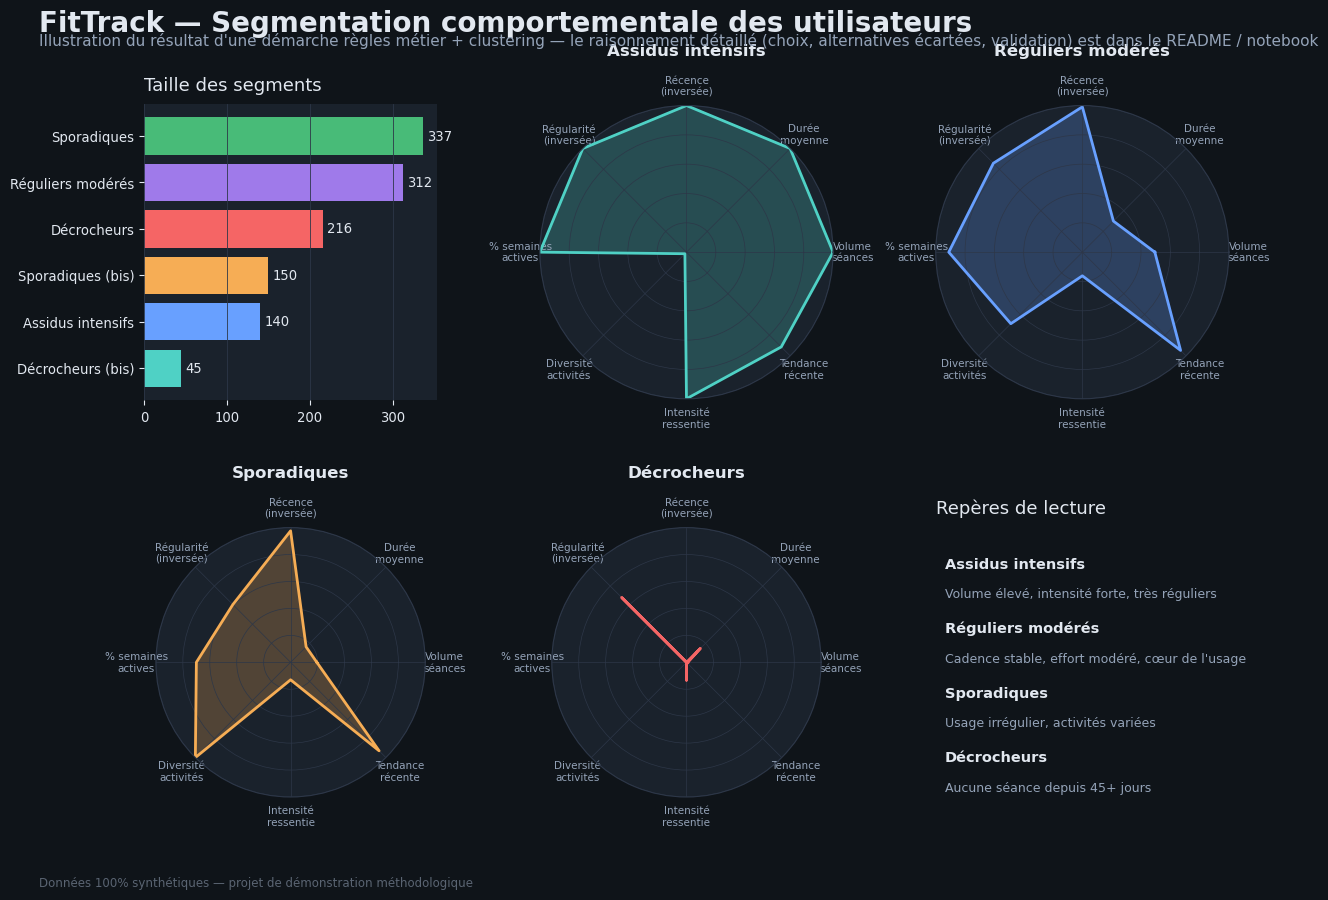

In [6]:
df_valid.to_csv("../data/utilisateurs_segmentes.csv", index=False)

import sys
sys.path.append("../src")
from make_dashboard import main as make_dashboard
make_dashboard()

## Limites et pistes d'amélioration

- Le nombre de sous-groupes par règle (2) est fixé arbitrairement ; une
  méthode statistique existante (le score de silhouette, qui mesure la
  qualité d'un regroupement) permettrait de le déterminer plus
  rigoureusement plutôt qu'à l'instinct.
- Les seuils des règles métier (45 jours, 60% de semaines actives...) sont
  des choix simples à valider avec une équipe produit sur des données
  réelles.
- Sur données réelles, il faudrait suivre la stabilité des segments dans le
  temps (un utilisateur change-t-il souvent de segment d'un mois à
  l'autre ?).
- La validation par profils générateurs prouve que la méthode retrouve une
  structure connue *sur des données calquées sur cette structure* — ce
  n'est pas une preuve de généralisation à un usage réel, où les frontières
  entre profils sont plus floues.

Ce qui reste, une fois ces réserves posées : un problème business
concret — des utilisateurs qui partent sans bruit —, traduit en indicateurs
justifiés, une méthode assumée, et une validation qui ne triche pas. Pour
FitTrack, ça veut dire une chose simple : savoir qui est en train de partir
avant qu'il ne soit trop tard, plutôt que de le découvrir dans un rapport le
mois suivant.

---
*FitTrack est une appli fictive de suivi sportif ; toutes les données de ce
notebook sont 100% synthétiques. Il s'agit d'un projet de démonstration
méthodologique, ne reflétant aucune donnée réelle d'un employeur ou d'un
tiers.*